In [ ]:
# !pip install matplotlib
# !pip install scikit-learn
# !pip install networkx
# !pip install umap-learn


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# ==========================================================
# Notebook 07: Thought Graph Visualization
# ==========================================================

import pickle
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

import networkx as nx

In [6]:
chunks_df = pd.read_csv("data/processed/chunked_corpus.csv")

with open("data/embeddings/chunk_embeddings.pkl", "rb") as file:

    embeddings = pickle.load(file)

embeddings = np.array(embeddings)

In [7]:
print("Embedding Shape:", embeddings.shape)

Embedding Shape: (2865, 384)


In [8]:
pca = PCA(n_components=2)

embedding_2d = pca.fit_transform(embeddings)

print(embedding_2d.shape)

(2865, 2)


In [10]:
visual_df = chunks_df.copy()

visual_df["x"] = embedding_2d[:, 0]
visual_df["y"] = embedding_2d[:, 1]

visual_df.head()

,chunk_id,source,category,created_date,chunk_text,x,y
0,1,2026-06-14.md,journal,2026-06-14,# Daily Journal\n\nToday I read about local AI...,-0.220701,-0.016256
1,2,ai_resume_matcher.md,project,NaN,# AI Resume Matcher\n\nToday I worked on the F...,-0.140782,-0.099214
2,3,book.pdf,book,NaN,Praise for Natural Language Processing with Tr...,-0.528211,-0.001530
3,4,book.pdf,book,NaN,NLP than the creators of said library? Natura...,-0.488142,-0.035812
4,5,book.pdf,book,NaN,insight and deftly mixes research advances wit...,-0.337267,-0.283377


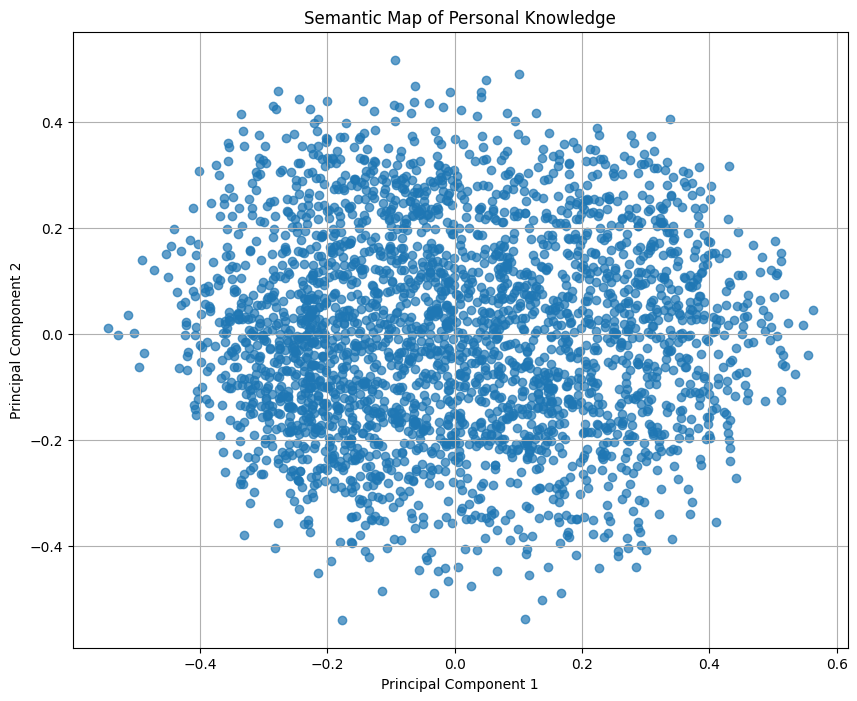

In [11]:
plt.figure(figsize=(10, 8))

plt.scatter(visual_df["x"], visual_df["y"], alpha=0.7)

plt.title("Semantic Map of Personal Knowledge")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.grid(True)

plt.show()

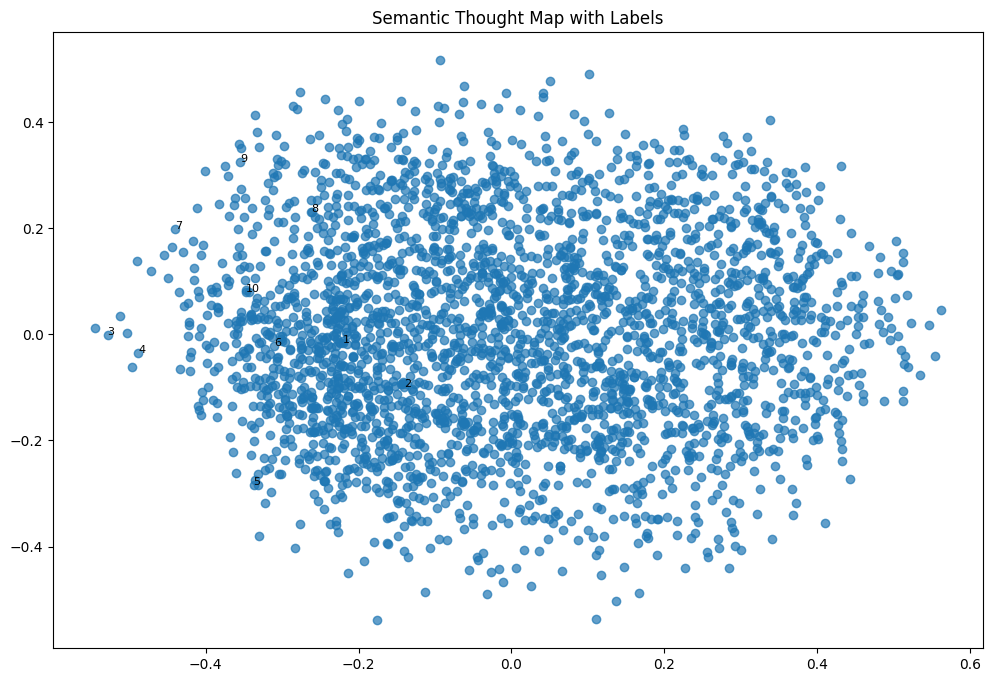

In [ ]:
plt.figure(figsize=(12, 8))

plt.scatter(visual_df["x"], visual_df["y"], alpha=0.7)

for idx in range(min(10, len(visual_df))):

    plt.text(
        visual_df.iloc[idx]["x"],
        visual_df.iloc[idx]["y"],
        str(visual_df.iloc[idx]["chunk_id"]),
        fontsize=8,
    )

plt.title("Semantic Thought Map with Labels")

plt.show()

In [13]:
similarity_matrix = cosine_similarity(embeddings)

print(similarity_matrix.shape)

(2865, 2865)


In [14]:
graph = nx.Graph()

In [15]:
for idx in range(len(chunks_df)):

    graph.add_node(idx, label=chunks_df.iloc[idx]["source"])

In [16]:
SIMILARITY_THRESHOLD = 0.75

for i in range(len(chunks_df)):

    for j in range(i + 1, len(chunks_df)):

        if similarity_matrix[i][j] > SIMILARITY_THRESHOLD:

            graph.add_edge(i, j, weight=float(similarity_matrix[i][j]))

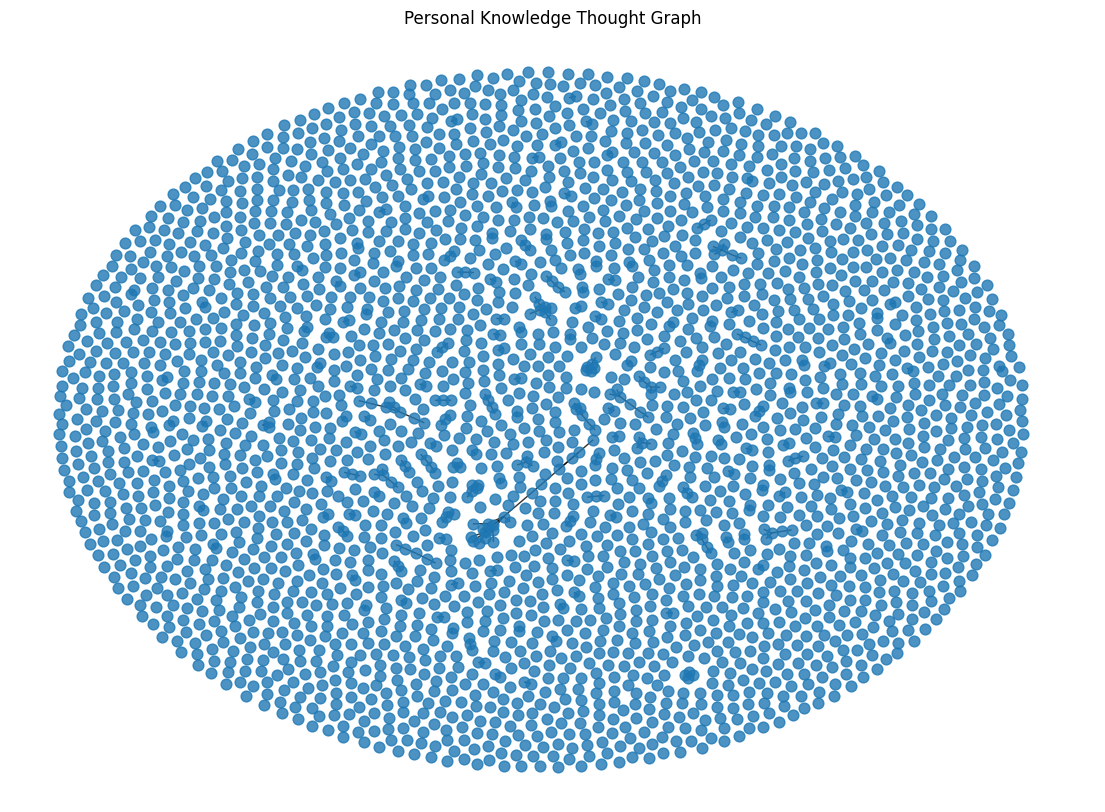

In [17]:
plt.figure(figsize=(14, 10))

positions = nx.spring_layout(graph, seed=42)

nx.draw_networkx(graph, pos=positions, with_labels=False, node_size=60, alpha=0.8)

plt.title("Personal Knowledge Thought Graph")

plt.axis("off")

plt.show()

In [18]:
target_node = 0

neighbors = list(graph.neighbors(target_node))

print(neighbors)

[]


In [19]:
for node in neighbors:

    print("-" * 50)

    print(chunks_df.iloc[node]["chunk_text"])

In [20]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

query = "How does semantic search work?"

query_embedding = model.encode(query)

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange
'(ProtocolError('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)), '(Request ID: 353346ba-13da-49a8-9e57-329e21ff7bf5)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json
Retrying in 1s [Retry 1/5].
d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [21]:
combined = np.vstack([embeddings, query_embedding])

query_pca = PCA(n_components=2).fit_transform(combined)

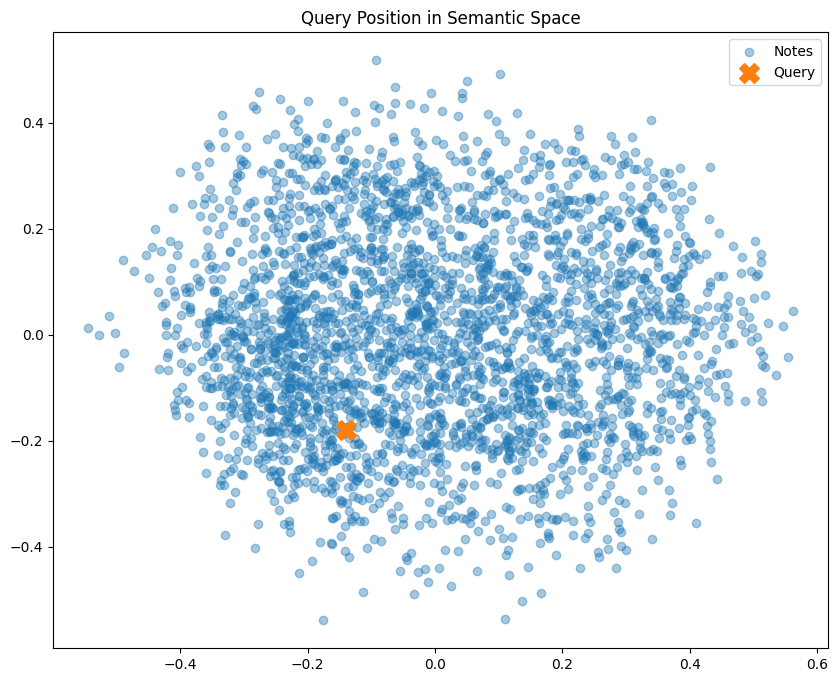

In [22]:
plt.figure(figsize=(10, 8))

plt.scatter(query_pca[:-1, 0], query_pca[:-1, 1], alpha=0.4, label="Notes")

plt.scatter(query_pca[-1, 0], query_pca[-1, 1], s=200, marker="X", label="Query")

plt.legend()

plt.title("Query Position in Semantic Space")

plt.show()

In [ ]:
import umap

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)

embedding_umap = reducer.fit_transform(embeddings)

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
